# ROGUE Purity Evaluation for cNMF + GSEA Pipeline

Complements `gsea_celltype_annotation.ipynb`. Two evaluations:

1. **Audit reference cell types** — compute ROGUE for each `global.cluster4` group. These are the GSEA gene sets; if any is impure, the GSEA NES scores conflate sub-states.
2. **Audit GEP-dominated groups per K** — for each K, assign each cell to its argmax-usage GEP, then compute ROGUE per group. Tracks how purity of cNMF-derived groupings evolves with K.

**Reference:** Liu et al., *Nat Commun* (2020). https://github.com/PaulingLiu/ROGUE

In [1]:
import os
import glob
import re
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
import time
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

import rpy2.robjects as ro
from rpy2.robjects import pandas2ri, numpy2ri
from rpy2.robjects.packages import importr

CONVERTER = ro.default_converter + pandas2ri.converter + numpy2ri.converter

rogue_r = importr('ROGUE')
tibble  = importr('tibble')

## 1. Configuration

Match these to your existing notebook + point at the raw-count AnnData you fed into cNMF.

In [2]:
# --- raw-count AnnData (same one used as cNMF input) ---
ADATA_PATH = "data/hnc_myeloid_2021.h5ad" 
COUNTS_LAYER = None  # set to a layer name if counts aren't in .X; else .X is used

# --- metadata ---
METADATA_PATH = "data/hnc_myeloid_globalcluster4.csv"
BARCODE_COL   = None
CELLTYPE_COL  = "global.cluster4"
METADATA_SEP  = ","

# --- cNMF outputs (must match GSEA notebook) ---
CNMF_DIR          = "hnc_consensus_outputs_k3-35/combined_hnc_k_consensus_outputs"
CNMF_PREFIX       = "combined_hnc_k"
DENSITY_THRESHOLD = "0_01"
K_MIN, K_MAX = 3, 35

# --- ROGUE params ---
ROGUE_PLATFORM = "UMI"   # 'UMI' (=droplet) or 'full-length'
ROGUE_SPECIES  = "Human" # 'Human' or 'Mouse'
ROGUE_K        = 45      # 45 for UMI, 500 for full-length; reference factor (NOT cNMF K)
MIN_CELLS_PER_GROUP = 15

OUT_DIR = "rogue_purity_results_5K_hvg"
os.makedirs(OUT_DIR, exist_ok=True)
print("Configuration loaded.")

Configuration loaded.


## 2. Load raw counts + metadata

In [3]:
adata = sc.read_h5ad(ADATA_PATH)
print(f"AnnData: {adata.shape}")

# Get raw counts as a dense genes × cells matrix (ROGUE expects this orientation)
X = adata.layers[COUNTS_LAYER] if COUNTS_LAYER else adata.X
if sparse.issparse(X):
    X = X.toarray()
X = X.astype(np.float64)

# Sanity check: ROGUE assumes raw counts (integer-valued, non-negative)
if not np.allclose(X, np.round(X)):
    raise ValueError("Matrix doesn't look like raw counts — check COUNTS_LAYER.")

counts_df = pd.DataFrame(X.T, index=adata.var_names, columns=adata.obs_names)
print(f"Counts matrix (genes × cells): {counts_df.shape}")

# Metadata
meta = pd.read_csv(METADATA_PATH, sep=METADATA_SEP,
                   index_col=0 if BARCODE_COL is None else None)
if BARCODE_COL is not None:
    meta = meta.set_index(BARCODE_COL)
meta.index = meta.index.astype(str)

common = counts_df.columns.intersection(meta.index)
counts_df = counts_df[common]
meta = meta.loc[common]
meta['orig.ident'] = adata.obs.loc[meta.index, 'orig.ident'].astype(str)
print(f"Aligned to {len(common)} cells")

AnnData: (26444, 23630)
Counts matrix (genes × cells): (23630, 26444)
Aligned to 26444 cells


## 3. ROGUE wrapper

Calls the R `rogue()` function on a counts matrix + per-cell labels and returns a tidy DataFrame. ROGUE returns a samples × clusters matrix (NaN where a cluster isn't present in a sample); we collapse by taking the mean across samples for a single per-cluster value.

In [4]:
def compute_rogue(counts_df, labels, samples=None,
                  platform=ROGUE_PLATFORM, species=ROGUE_SPECIES,
                  k=ROGUE_K, min_cells=MIN_CELLS_PER_GROUP,
                  verbose=True):
    """
    counts_df : DataFrame (genes × cells), raw counts
    labels    : Series indexed by cell barcode → cluster label
    samples   : Series indexed by cell barcode → sample/patient ID, or None
    Returns   : (long DataFrame [sample, cluster, ROGUE, n_cells],
                 wide DataFrame [samples × clusters])
    """
    # --- Filter tiny groups ---
    label_counts = labels.value_counts()
    keep = label_counts[label_counts >= min_cells].index
    dropped = sorted(set(label_counts.index) - set(keep))
    if dropped and verbose:
        print(f"Skipping {len(dropped)} cluster(s) below {min_cells} cells: {dropped}")

    cells = labels[labels.isin(keep)].index
    counts_sub = counts_df[cells]
    labels_sub = labels.loc[cells].astype(str)
    samples_sub = (pd.Series("all", index=cells) if samples is None
                   else samples.loc[cells].astype(str))

    # --- Build (sample, cluster) work list ---
    pairs = (pd.DataFrame({'sample': samples_sub.values, 'cluster': labels_sub.values})
               .value_counts()
               .reset_index(name='n_cells'))
    pairs = pairs[pairs['n_cells'] >= min_cells].reset_index(drop=True)

    if verbose:
        print(f"Counts: {counts_sub.shape[0]:,} genes × {counts_sub.shape[1]:,} cells")
        print(f"Computing ROGUE for {len(pairs)} (sample, cluster) pair(s)")
        for _, r in pairs.iterrows():
            print(f"  {r['sample']} / {r['cluster']}: {r['n_cells']} cells")
        print()

    # --- Push the full counts matrix to R once ---
    with CONVERTER.context():
        ro.globalenv['expr_full'] = counts_sub
    ro.r('''
        suppressMessages(library(ROGUE))
        expr_full <- as.matrix(expr_full)
    ''')

    # --- Per-(sample, cluster) loop in Python ---
    results = []
    t_total = time.time()
    iterator = tqdm(list(pairs.itertuples(index=False)),
                    total=len(pairs), disable=not verbose,
                    desc="ROGUE")

    for row in iterator:
        s, ct, n = row.sample, row.cluster, row.n_cells
        in_mask = (samples_sub == s) & (labels_sub == ct)
        sub_cells = labels_sub.index[in_mask].tolist()

        with CONVERTER.context():
            ro.globalenv['cells_keep'] = ro.StrVector(sub_cells)

        t0 = time.time()
        try:
            ro.r(f'''
                expr_mat  <- expr_full[, cells_keep, drop=FALSE]
                expr_mat  <- matr.filter(expr_mat, min.cells = 10, min.genes = 10)
                ent_res   <- SE_fun(expr_mat, span = 0.6, mt.method = "fdr")
                rogue_val <- CalculateRogue(ent_res, platform = "{platform}", k = {k})
            ''')
            with CONVERTER.context():
                rogue_val = float(ro.r('rogue_val')[0])
            ok = True
        except Exception as e:
            rogue_val = float('nan')
            ok = False
            if verbose:
                tqdm.write(f"  ✗ {s} / {ct}: FAILED — {e}")

        elapsed = time.time() - t0
        if ok and verbose:
            tqdm.write(f"  ✓ {s} / {ct:<25} ROGUE={rogue_val:.3f}  "
                       f"(n={n:>4}, {elapsed:>4.1f}s)")

        results.append({'sample': s, 'cluster': ct,
                        'ROGUE': rogue_val, 'n_cells': n})

    total = time.time() - t_total
    if verbose:
        avg = total / max(len(pairs), 1)
        print(f"\nDone in {total:.1f}s total ({avg:.1f}s/cluster avg)")

    long = pd.DataFrame(results).dropna(subset=['ROGUE']).reset_index(drop=True)
    wide = long.pivot(index='sample', columns='cluster', values='ROGUE')
    return long, wide

## 4. Application 1 — Audit the reference cell type annotations

These labels are the "gene sets" in your GSEA. Any cluster with ROGUE < ~0.9 is heterogeneous; GEPs that GSEA assigns to it may be capturing a sub-state, not the full label.

In [5]:
# Optionally split by sample/patient if you have a column for it
# samples = meta['patient_id']  # uncomment if available
samples = meta['orig.ident']

ct_csv = f"{OUT_DIR}/rogue_celltype_audit.csv"
if os.path.exists(ct_csv):
    print(f"Found existing {ct_csv} — loading instead of recomputing.")
    ct_long = pd.read_csv(ct_csv)
else:
    ct_long, ct_wide = compute_rogue(
        counts_df,
        labels=meta[CELLTYPE_COL],
        samples=samples,
    )
    ct_long.to_csv(ct_csv, index=False)

# Summarize: median ROGUE per cluster (across samples, if any)
ct_summary = (ct_long.groupby('cluster')
                     .agg(median_ROGUE=('ROGUE', 'median'),
                          mean_ROGUE  =('ROGUE', 'mean'),
                          n_samples   =('ROGUE', 'count'),
                          total_cells =('n_cells', 'sum'))
                     .sort_values('median_ROGUE'))
ct_summary

Found existing rogue_purity_results_5K_hvg/rogue_celltype_audit.csv — loading instead of recomputing.


,median_ROGUE,mean_ROGUE,n_samples,total_cells
cluster,,,,
Mac_SPP1,0.625583,0.656306,7,532
cDC2_CD1C,0.640848,0.647154,21,886
Mac_IL1Bint,0.682749,0.685116,21,1792
Mac_CXCL9,0.720893,0.710826,13,1139
Mac_IL1B,0.748475,0.738859,10,722
mregDC_LAMP3,0.752654,0.766246,12,380
Mono_TIL,0.763075,0.766121,13,913
cDC1_CLEC9A,0.815049,0.809760,6,162
cDC2_CD33,0.870551,0.856640,36,1185


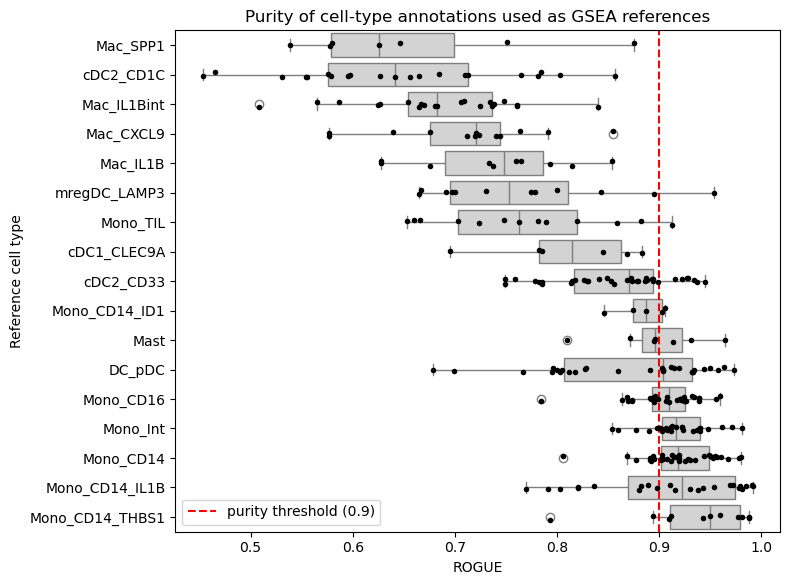

In [6]:
# Plot — flag clusters below 0.9
fig, ax = plt.subplots(figsize=(8, max(3, 0.35 * len(ct_summary))))
order = ct_summary.index
sns.boxplot(data=ct_long, y='cluster', x='ROGUE', order=order, color='lightgray', ax=ax)
sns.stripplot(data=ct_long, y='cluster', x='ROGUE', order=order, color='black', size=4, ax=ax)
ax.axvline(0.9, ls='--', color='red', label='purity threshold (0.9)')
ax.set_xlabel('ROGUE')
ax.set_ylabel('Reference cell type')
ax.set_title('Purity of cell-type annotations used as GSEA references')
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/rogue_celltype_audit.png", dpi=150)
plt.show()

## 5. Application 2 — ROGUE per GEP-dominated cell group, scanned across K

For each K: load the usage matrix, assign each cell to `argmax(usage)` GEP, compute ROGUE per GEP. This tells you whether the cells most-strongly-driven by each GEP form a homogeneous population — a GEP-centric purity score that's complementary to the cell-type-centric NES from your GSEA notebook.

**Gene-space note:** unlike §4, this section runs ROGUE on the **same 5,000 highly variable genes that cNMF used as its substrate** (selected via `scanpy.pp.highly_variable_genes` with `flavor='seurat_v3'` on raw counts; see §5.0 below). Rationale: a GEP can only model heterogeneity in genes cNMF was given access to, so its purity should be evaluated on that same gene space. Note that this **shifts the absolute ROGUE scale downward** vs. the full-transcriptome reference in §4 — ROGUE's S-E test is calibrated against the whole-transcriptome mean–variance trend, and restricting to pre-selected HVGs biases the entropy reference. Compare K-to-K within §5, but do **not** compare §5 ROGUE values directly to §4 or to the 0.9 threshold from Liu et al. (2020).

### 5.0. Select the 5K highly variable genes (cNMF substrate)

We compute HVGs once on the raw counts using `flavor='seurat_v3'` (which is designed for un-normalized counts and is what cNMF's own pipeline uses internally). All §5 ROGUE calls below operate on `counts_df_hvg` instead of the full `counts_df`.

In [7]:
N_HVG = 5000

# Build a temporary AnnData on raw counts so we can use scanpy's HVG selector.
# We pass cells × genes here (the standard AnnData orientation).
_hvg_adata = ad.AnnData(
    X=counts_df.T.values,                     # cells × genes
    obs=pd.DataFrame(index=counts_df.columns),
    var=pd.DataFrame(index=counts_df.index),
)

sc.pp.highly_variable_genes(
    _hvg_adata,
    n_top_genes=N_HVG,
    flavor='seurat_v3',   # operates on raw counts; matches cNMF's expectation
    subset=False,
)

hvg_genes = _hvg_adata.var_names[_hvg_adata.var['highly_variable']].tolist()
print(f"Selected {len(hvg_genes)} HVGs out of {counts_df.shape[0]} total genes.")

# Restricted counts matrix used for all §5 ROGUE calls
counts_df_hvg = counts_df.loc[hvg_genes]
print(f"HVG counts matrix (genes × cells): {counts_df_hvg.shape}")

# Persist the gene list so the choice is reproducible/auditable
hvg_path = os.path.join(OUT_DIR, f"hvg_genes_n{N_HVG}_seuratv3.txt")
pd.Series(hvg_genes).to_csv(hvg_path, index=False, header=False)
print(f"  → saved gene list to {hvg_path}")

del _hvg_adata

Selected 5000 HVGs out of 23630 total genes.
HVG counts matrix (genes × cells): (5000, 26444)
  → saved gene list to rogue_purity_results_5K_hvg/hvg_genes_n5000_seuratv3.txt


In [8]:
# Discover available K values (same logic as your GSEA notebook)
usage_pattern = os.path.join(
    CNMF_DIR, f"{CNMF_PREFIX}.usages.k_*.dt_{DENSITY_THRESHOLD}.consensus.txt"
)
k_values = []
for f in sorted(glob.glob(usage_pattern)):
    m = re.search(r'k_(\d+)', os.path.basename(f))
    if m:
        k = int(m.group(1))
        if K_MIN <= k <= K_MAX:
            k_values.append(k)
k_values = sorted(set(k_values))
print(f"K values: {k_values}")

K values: [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35]


In [9]:
all_gep_rogue = {}  # k -> long DataFrame (kept in-memory for §5a/5b plots)

# Cached results from this HVG-restricted run live under a separate filename
# so they don't collide with any pre-existing full-transcriptome results.
def _gep_out_path(k):
    return os.path.join(OUT_DIR, f"rogue_per_gep_hvg_K{k}.csv")

# Identify which Ks already have outputs on disk
existing_ks, missing_ks = [], []
for k in k_values:
    out_path = _gep_out_path(k)
    if os.path.exists(out_path):
        existing_ks.append(k)
    else:
        missing_ks.append(k)

# Load any existing per-K results so downstream plots have all Ks available
if existing_ks:
    print(f"Found existing HVG outputs for K = {existing_ks} — loading from disk.")
    for k in existing_ks:
        all_gep_rogue[k] = pd.read_csv(_gep_out_path(k))

if not missing_ks:
    print("All Ks already computed — skipping ROGUE computation.")
else:
    print(f"Computing ROGUE for missing K = {missing_ks}")
    print(f"Gene space: {counts_df_hvg.shape[0]} HVGs (cNMF substrate)")
    for k in missing_ks:
        usage_path = os.path.join(
            CNMF_DIR, f"{CNMF_PREFIX}.usages.k_{k}.dt_{DENSITY_THRESHOLD}.consensus.txt"
        )
        usage = pd.read_csv(usage_path, sep='\t', index_col=0)
        usage.index = usage.index.astype(str)

        cells = usage.index.intersection(counts_df_hvg.columns)
        usage = usage.loc[cells]

        # Hard-assign each cell to its dominant GEP
        gep_labels = usage.idxmax(axis=1).astype(str).rename('GEP')
        gep_labels.index.name = None

        print(f"\n{'='*60}\nK={k}: {len(cells)} cells across {usage.shape[1]} GEPs\n{'='*60}")

        long, wide = compute_rogue(
            counts_df_hvg[cells],
            labels=gep_labels,
            samples=samples.loc[cells] if samples is not None else None,
        )
        long['K'] = k

        # Save this K's results immediately
        out_path = _gep_out_path(k)
        long.to_csv(out_path, index=False)
        print(f"  → saved {out_path}")

        all_gep_rogue[k] = long


Computing ROGUE for missing K = [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35]
Gene space: 5000 HVGs (cNMF substrate)

K=3: 26444 cells across 3 GEPs
Counts: 5,000 genes × 26,444 cells
Computing ROGUE for 113 (sample, cluster) pair(s)
  GSM4138134 / 1: 1213 cells
  GSM4138156 / 1: 921 cells
  GSM4138126 / 1: 758 cells
  GSM4138135 / 2: 757 cells
  GSM4138116 / 1: 704 cells
  GSM4138140 / 1: 702 cells
  GSM4138142 / 1: 689 cells
  GSM4138132 / 1: 643 cells
  GSM4138136 / 1: 641 cells
  GSM4138110 / 1: 628 cells
  GSM4138120 / 1: 609 cells
  GSM4138137 / 2: 609 cells
  GSM4138123 / 2: 597 cells
  GSM4138130 / 1: 586 cells
  GSM4138138 / 1: 577 cells
  GSM4138128 / 1: 545 cells
  GSM4138122 / 1: 545 cells
  GSM4138131 / 2: 538 cells
  GSM4138139 / 2: 502 cells
  GSM4138162 / 1: 485 cells
  GSM4138160 / 1: 485 cells
  GSM4138155 / 2: 472 cells
  GSM4138166 / 1: 468 cells
  GSM4138152 / 1: 462 cells
  GSM4138146 

ROGUE:   0%|          | 0/113 [00:00<?, ?it/s]

  ✓ GSM4138134 / 1                         ROGUE=0.938  (n=1213,  0.6s)
  ✓ GSM4138156 / 1                         ROGUE=0.887  (n= 921,  0.0s)
  ✓ GSM4138126 / 1                         ROGUE=0.952  (n= 758,  0.0s)
  ✓ GSM4138135 / 2                         ROGUE=0.656  (n= 757,  0.1s)
  ✓ GSM4138116 / 1                         ROGUE=0.917  (n= 704,  0.0s)
  ✓ GSM4138140 / 1                         ROGUE=0.913  (n= 702,  0.0s)
  ✓ GSM4138142 / 1                         ROGUE=0.894  (n= 689,  0.0s)
  ✓ GSM4138132 / 1                         ROGUE=0.925  (n= 643,  0.1s)
  ✓ GSM4138136 / 1                         ROGUE=0.900  (n= 641,  0.1s)
  ✓ GSM4138110 / 1                         ROGUE=0.919  (n= 628,  0.1s)
  ✓ GSM4138120 / 1                         ROGUE=0.835  (n= 609,  0.0s)
  ✓ GSM4138137 / 2                         ROGUE=0.702  (n= 609,  0.0s)
  ✓ GSM4138123 / 2                         ROGUE=0.637  (n= 597,  0.1s)
  ✓ GSM4138130 / 1                         ROGUE=0.914  (n= 586,

ROGUE:   0%|          | 0/126 [00:00<?, ?it/s]

  ✓ GSM4138134 / 1                         ROGUE=0.938  (n=1213,  0.3s)
  ✓ GSM4138156 / 1                         ROGUE=0.890  (n= 919,  0.1s)
  ✓ GSM4138126 / 1                         ROGUE=0.952  (n= 758,  0.0s)
  ✓ GSM4138116 / 1                         ROGUE=0.919  (n= 703,  0.0s)
  ✓ GSM4138140 / 1                         ROGUE=0.918  (n= 700,  0.1s)
  ✓ GSM4138142 / 1                         ROGUE=0.894  (n= 689,  0.0s)
  ✓ GSM4138132 / 1                         ROGUE=0.925  (n= 643,  0.1s)
  ✓ GSM4138136 / 1                         ROGUE=0.900  (n= 641,  0.1s)
  ✓ GSM4138110 / 1                         ROGUE=0.919  (n= 628,  0.1s)
  ✓ GSM4138120 / 1                         ROGUE=0.835  (n= 609,  0.0s)
  ✓ GSM4138130 / 1                         ROGUE=0.915  (n= 585,  0.0s)
  ✓ GSM4138138 / 1                         ROGUE=0.895  (n= 576,  0.0s)
  ✓ GSM4138123 / 2                         ROGUE=0.637  (n= 562,  0.1s)
  ✓ GSM4138122 / 1                         ROGUE=0.888  (n= 543,

...

  ✓ GSM4138134 / 3                         ROGUE=0.932  (n= 669,  0.1s)
  ✓ GSM4138156 / 3                         ROGUE=0.902  (n= 594,  0.0s)
  ✓ GSM4138120 / 2                         ROGUE=0.827  (n= 460,  0.0s)
  ✓ GSM4138126 / 3                         ROGUE=0.965  (n= 447,  0.0s)
  ✓ GSM4138123 / 2                         ROGUE=0.656  (n= 432,  0.1s)
  ✓ GSM4138132 / 3                         ROGUE=0.937  (n= 414,  0.0s)
  ✓ GSM4138145 / 2                         ROGUE=0.694  (n= 401,  0.0s)
  ✓ GSM4138155 / 2                         ROGUE=0.567  (n= 401,  0.0s)
  ✓ GSM4138131 / 2                         ROGUE=0.674  (n= 393,  0.1s)
  ✓ GSM4138134 / 2                         ROGUE=0.930  (n= 390,  0.0s)
  ✓ GSM4138130 / 3                         ROGUE=0.902  (n= 373,  0.0s)
  ✓ GSM4138152 / 2                         ROGUE=0.852  (n= 366,  0.0s)
  ✓ GSM4138141 / 2                         ROGUE=0.683  (n= 357,  0.0s)
  ✓ GSM4138116 / 3                         ROGUE=0.948  (n= 331,

ROGUE:   0%|          | 0/237 [00:00<?, ?it/s]

  ✓ GSM4138134 / 1                         ROGUE=0.928  (n= 705,  0.1s)
  ✓ GSM4138156 / 1                         ROGUE=0.877  (n= 595,  0.1s)
  ✓ GSM4138120 / 1                         ROGUE=0.832  (n= 520,  0.0s)
  ✓ GSM4138116 / 1                         ROGUE=0.909  (n= 506,  0.0s)
  ✓ GSM4138140 / 1                         ROGUE=0.899  (n= 471,  0.0s)
  ✓ GSM4138126 / 1                         ROGUE=0.941  (n= 471,  0.0s)
  ✓ GSM4138142 / 1                         ROGUE=0.885  (n= 466,  0.1s)
  ✓ GSM4138110 / 1                         ROGUE=0.909  (n= 441,  0.0s)
  ✓ GSM4138122 / 1                         ROGUE=0.886  (n= 435,  0.0s)
  ✓ GSM4138128 / 1                         ROGUE=0.886  (n= 435,  0.0s)
  ✓ GSM4138136 / 1                         ROGUE=0.888  (n= 424,  0.0s)
  ✓ GSM4138152 / 1                         ROGUE=0.855  (n= 401,  0.0s)
  ✓ GSM4138162 / 1                         ROGUE=0.884  (n= 387,  0.0s)
  ✓ GSM4138130 / 1                         ROGUE=0.919  (n= 379,

ROGUE:   0%|          | 0/256 [00:00<?, ?it/s]

  ✓ GSM4138134 / 1                         ROGUE=0.921  (n= 696,  0.1s)
  ✓ GSM4138156 / 1                         ROGUE=0.875  (n= 627,  0.1s)
  ✓ GSM4138120 / 1                         ROGUE=0.830  (n= 533,  0.0s)
  ✓ GSM4138126 / 1                         ROGUE=0.946  (n= 529,  0.0s)
  ✓ GSM4138116 / 1                         ROGUE=0.914  (n= 500,  0.0s)
  ✓ GSM4138142 / 1                         ROGUE=0.893  (n= 488,  0.0s)
  ✓ GSM4138140 / 1                         ROGUE=0.903  (n= 481,  0.0s)
  ✓ GSM4138110 / 1                         ROGUE=0.901  (n= 452,  0.0s)
  ✓ GSM4138122 / 1                         ROGUE=0.884  (n= 442,  0.0s)
  ✓ GSM4138128 / 1                         ROGUE=0.884  (n= 442,  0.3s)
  ✓ GSM4138130 / 1                         ROGUE=0.899  (n= 432,  0.0s)
  ✓ GSM4138136 / 1                         ROGUE=0.890  (n= 415,  0.0s)
  ✓ GSM4138162 / 1                         ROGUE=0.875  (n= 401,  0.0s)
  ✓ GSM4138152 / 1                         ROGUE=0.844  (n= 396,

In [10]:
gep_rogue_long = pd.concat(all_gep_rogue.values(), ignore_index=True)

### 5a. Mean ROGUE vs K — a purity-based aid for K selection

Read this together with your hierarchical-tree analysis. Where ROGUE plateaus, you've stopped resolving meaningfully purer programs; further K just shaves cells off existing GEPs.

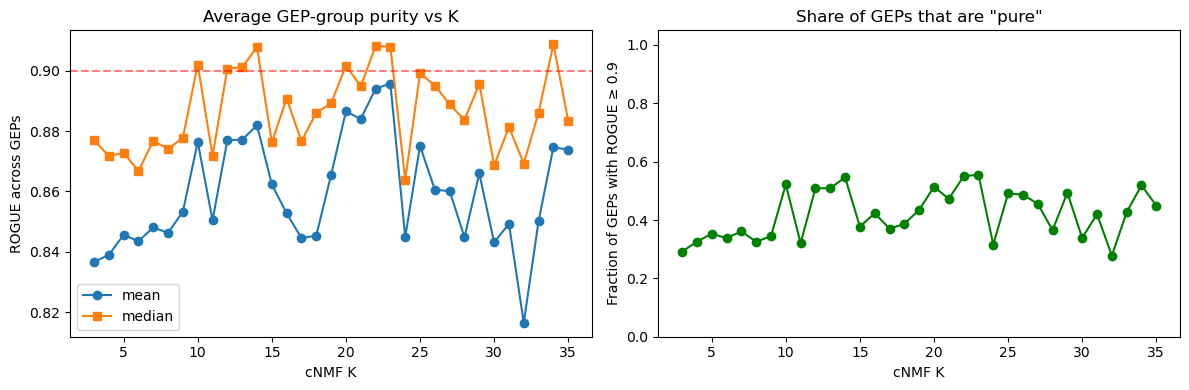

,K,mean_ROGUE,median_ROGUE,min_ROGUE,frac_pure
0,3,0.836584,0.877052,0.533557,0.292035
1,4,0.838972,0.871740,0.574793,0.325397
2,5,0.845570,0.872789,0.576450,0.353383
3,6,0.843516,0.866779,0.591485,0.337838
4,7,0.848045,0.876802,0.611579,0.360947
5,8,0.846277,0.874036,0.625158,0.325581
6,9,0.853305,0.877815,0.626619,0.344444
7,10,0.876402,0.902059,0.627562,0.521930
8,11,0.850448,0.871713,0.626453,0.320225
9,12,0.876998,0.900712,0.631553,0.508772


In [11]:
k_summary = (gep_rogue_long
             .groupby('K')
             .agg(mean_ROGUE  =('ROGUE', 'mean'),
                  median_ROGUE=('ROGUE', 'median'),
                  min_ROGUE   =('ROGUE', 'min'),
                  frac_pure   =('ROGUE', lambda x: (x >= 0.9).mean()))
             .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_summary['K'], k_summary['mean_ROGUE'], marker='o', label='mean')
axes[0].plot(k_summary['K'], k_summary['median_ROGUE'], marker='s', label='median')
axes[0].axhline(0.9, ls='--', color='red', alpha=0.5)
axes[0].set(xlabel='cNMF K', ylabel='ROGUE across GEPs',
            title='Average GEP-group purity vs K')
axes[0].legend()

axes[1].plot(k_summary['K'], k_summary['frac_pure'], marker='o', color='green')
axes[1].set(xlabel='cNMF K', ylabel='Fraction of GEPs with ROGUE ≥ 0.9',
            title='Share of GEPs that are "pure"', ylim=(0, 1.05))
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/rogue_vs_K.png", dpi=150)
plt.show()
k_summary